# Sobre o dataset

O dataset apresentado se trata de metricas de partidas de um jogo MOBA chamado League of Legends. No dataset fornecido temos as um total de 9879 linhas e 40 calunas com as seguintes informacoes.<br>

### Primeira parte

**gameId** -> Identificador da partida (feature inutil) <br>
**blueWins** -> Vitoria do time azul 0 para derrota e 1 para vitoria, consequentimente 0 significa vitoria do time vermelho.
**blueWardsPlaced** -> Numero de wards colocadas pelo time azul. <br>
**blueWardsDestroyed** -> Numero de wards do time vermelho destruidas pelo azul. <br>
**blueFirstBlood** -> Primeiro abate do time azul 0 para true 1 para false <br>
**blueKills** -> Quantidade total de abates do time azul <br>
**blueDeaths** -> Quantidade total de mortes do time azul <br>
**blueAssists** -> Quantidade total de assistencia de abates do time azul <br>
**blueEliteMonsters** -> Quantidade total de monstros abatidos (Barao Nashor, dragoes, arauto, atakkan vastilarvas) pelo time azul <br>
**blueDragons** -> Quantidade total de dragoes abatidos pelo time azul <br>
**blueHeralds** -> Quantidade total de arautos abatidos pelo time azul <br>
**blueTowersDestroyed** -> Quantidade total de torres destruidas pelo time azul <br>
**blueTotalGold** -> Total de outro adquirido pelo time  azul <br>
**blueAvgLevel** -> Media de nivel dos jogadores do time azul <br>
**blueTotalExperience** -> Total de XP que o time azul adquiriu <br>
**blueTotalMinionsKilled** -> Total de minions abatidos pelo time azul <br>
**blueTotalJungleMinionsKilled** -> Total de seres da selva abatidos pelo time azul <br>
**blueGoldDiff** -> Diferenca entre o total de ouro do time azul menos o do time vermelho <br>
**blueExperienceDiff** -> Diferenca entre a total experiencia do time azul menos a do time vermelho <br>
**blueCSPerMin** -> Quantidade total de farm por minuto entre os jogadores do time azul <br>
**blueGoldPerMin** -> Quantidade de ouro por minuto adquirido pelo time azul <br>

### Segunda parte

**redWardsPlaced** -> Numero de wards colocadas pelo time Vermelho. <br>
**redWardsDestroyed** ->  Numero de wards do time azul destruidas pelo vermelho. <br>
**redFirstBlood** -> Primeiro abate do time vermelho 0 para true 1 para false <br>
**redKills** -> Quantidade total de abates do time vermelho <br>
**redDeaths** -> Quantidade total de mortes do time vermelho <br>
**redAssists** -> Quantidade total de assistencia de abates do time vermelho <br>
**redEliteMonsters** -> Quantidade total de monstros abatidos (Barao Nashor, dragoes, arauto, atakkan vastilarvas) pelo time vermelho <br>
**redDragons** -> Quantidade total de dragoes abatidos pelo time vermelho <br>
**redHeralds** -> Quantidade total de arautos abatidos pelo time vermelho <br>
**redTowersDestroyed** -> Quantidade total de torres destruidas pelo time vermelho <br>
**redTotalGold** -> Total de outro adquirido pelo time  vermelho <br>
**redAvgLevel** -> Media de nivel dos jogadores do time vermelho <br>
**redTotalExperience** -> Total de XP que o time vermelho adquiriu <br>
**redTotalMinionsKilled** -> Total de minions abatidos pelo time vermelho <br>
**redTotalJungleMinionsKilled** -> Total de seres da selva abatidos pelo time vermelho <br>
**redGoldDiff** ->  Diferenca entre o total de ouro do time vermelho menos o do time azul <br>
**redExperienceDiff** ->  Diferenca entre a total experiencia do time vermelho menos a do time azul <br>
**redCSPerMin** -> Quantidade total de farm por minuto entre os jogadores do time vermelho <br>
**redGoldPerMin** -> Quantidade de ouro por minuto adquirido pelo time vermelho <br>


# Objetivo

Temos aqui como objetivo e entender quais metricas aumentam as chances de vitoria de um jogo e quais sao irrelevantes ou pouco influenciam

### Ferramentas

Usaremos como ferramentas graficos e funcoes para realizar analise univariada e bivariada, tambem aplicaremos e claro tecnicas de machine learning para predizer quais sao as chances de vitoria. Como e evidente que o nosso problema e de classificacao, utilizaremos random forest ou XGBosst por lidar muito bem com muitas features

In [1]:
# Manipulacao de dados
import pandas as pd

# Visualizacao de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Avaliacao de metricas
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# Pos modelo
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate



In [2]:
# Buscando e analisando o dataframe visualmente
df = pd.read_csv('Base_M43_Pratique_LOL_RANKED_WIN.csv')
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [3]:
# De cara dropando a coluna ID por nao ter influencia nenhuma na nossa analise
df = df.drop(columns='gameId', axis=1)

In [4]:
# Aferindo os tipos de dados e ao mesmo tempo observando se a algum dado faltante ou nulo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   blueWins                      9879 non-null   int64  
 1   blueWardsPlaced               9879 non-null   int64  
 2   blueWardsDestroyed            9879 non-null   int64  
 3   blueFirstBlood                9879 non-null   int64  
 4   blueKills                     9879 non-null   int64  
 5   blueDeaths                    9879 non-null   int64  
 6   blueAssists                   9879 non-null   int64  
 7   blueEliteMonsters             9879 non-null   int64  
 8   blueDragons                   9879 non-null   int64  
 9   blueHeralds                   9879 non-null   int64  
 10  blueTowersDestroyed           9879 non-null   int64  
 11  blueTotalGold                 9879 non-null   int64  
 12  blueAvgLevel                  9879 non-null   float64
 13  blu

In [5]:
# Confirmando se nossa coluna target realmente possui somente valores 0 e 1
df['blueWins'].unique()

array([0, 1])

In [6]:
# Transformando em booleano
df['blueWins'] = df['blueWins'].astype(bool)

# Analise exploratoria de dados - EDA

In [8]:
# Analisando de maneira grosseira a existencia de outilers ou quaisquer anomalias
df.describe()

,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,0.187974,0.051422,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,0.390712,0.244369,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,1.000000,4.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


### Diff dos graficos

Nosso dataframe possui 39 colunas, isso dificulta muito nossa analise. Como se trata de dois times precisamos criar um novo dataframe onde temos a diferenca do azul - o vermelho
se a variavel ficar negativa significa que o vermelho sobressaiu se ficar positiva o azul sobressaiu de forma correlacionada, fica muito mais limpo, facil de analisar, visualizar e criamos variaveis mais fortes.

Primariamente tinha criado linha por linha da forma tradicional "d*f['coluna_diff'] = df['coluna_azul'] - df['coluna_vermelha']*", porem ficou enorme e sujo, nao senti nada de profissionalismo. Tentei novamente usando estruturas de repeticao, mas tive dificuldades e nao ficava como queria , entao andei pesquisando e consegui encontrar a melhor forma de fazer de maneira limpa e organizada

In [9]:

diff_features = {} # Criando um dicionário vazio para armazenar novas colunas

for col in df.columns: # O "for" vai percorrer coluna por coluna do dataframe
    if col.startswith("blue"): # Primeira condicao - "col" vai comecar apenas com a coluna azul
        red_col = col.replace("blue", "red") # Então trocaremos todos os azuis por vermelho e armazenaremos

        if red_col in df.columns: # Segunda condicao - so ira transformar as colunas se existir uma coluna em red_col igual em df.columns
            diff_name = "diff_" + col[4:] # Criando uma chave no qual retira os 4 primeiros caracteres e substitui por "diff_"
            diff_features[diff_name] = df[col] - df[red_col] # Por fim trazendo a diferença entre blue - read e mudando o nome


df_only_diff = pd.DataFrame(diff_features) # Criando um dataframe que vai receber o dicionario
df_only_diff["target"] = df["blueWins"] # Renomeando a coluna blueWins para target

df_only_diff

,diff_WardsPlaced,diff_WardsDestroyed,diff_FirstBlood,diff_Kills,diff_Deaths,diff_Assists,diff_EliteMonsters,diff_Dragons,diff_Heralds,diff_TowersDestroyed,diff_TotalGold,diff_AvgLevel,diff_TotalExperience,diff_TotalMinionsKilled,diff_TotalJungleMinionsKilled,diff_GoldDiff,diff_ExperienceDiff,diff_CSPerMin,diff_GoldPerMin,target
0,13,-4,1,3,-3,3,0,0,0,0,643,-0.2,-8,-2,-19,1286,-16,-0.2,64.3,False
1,0,0,-1,0,0,3,-2,-1,-1,-1,-2908,-0.2,-1173,-66,-9,-5816,-2346,-6.6,-290.8,False
2,0,-3,-1,-4,4,-10,1,1,0,0,-1172,-0.4,-1033,-17,18,-2344,-2066,-1.7,-117.2,False
3,28,-1,-1,-1,1,-5,1,0,1,0,-1321,0.0,-7,-34,8,-2642,-14,-3.4,-132.1,False
4,58,2,-1,0,0,-1,-1,-1,0,0,-1004,0.0,230,-15,-10,-2008,460,-1.5,-100.4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,-29,-1,1,3,-3,-2,1,1,0,0,2519,0.4,2469,-18,35,5038,4938,-1.8,251.9,True
9875,42,-21,-1,2,-2,5,1,1,0,0,782,0.2,888,27,-8,1564,1776,2.7,78.2,True
9876,9,1,-1,-1,1,-6,-1,-1,0,0,-2416,-0.4,-1877,-51,-15,-4832,-3754,-5.1,-241.6,False
9877,-52,0,1,-1,1,2,1,1,0,0,-839,-0.6,-1085,-23,8,-1678,-2170,-2.3,-83.9,False


## Analisando a correlacao  entre a target

In [10]:
# Analisando a correlacao entre as features e a target em ordem decrescente
df_only_diff.corr()['target'].sort_values(ascending=False)

target                           1.000000
diff_TotalGold                   0.511119
diff_GoldDiff                    0.511119
diff_GoldPerMin                  0.511119
diff_TotalExperience             0.489558
diff_ExperienceDiff              0.489558
diff_Kills                       0.479379
diff_AvgLevel                    0.452927
diff_Assists                     0.385866
diff_TotalMinionsKilled          0.309126
diff_CSPerMin                    0.309126
diff_EliteMonsters               0.259969
diff_Dragons                     0.234264
diff_FirstBlood                  0.201769
diff_TotalJungleMinionsKilled    0.169118
diff_TowersDestroyed             0.156179
diff_Heralds                     0.121713
diff_WardsDestroyed              0.075205
diff_WardsPlaced                 0.016890
diff_Deaths                     -0.479379
Name: target, dtype: float64

In [11]:
# Removendo colunas redundantes
colunas_para_remover = [
    "diff_GoldDiff",
    "diff_GoldPerMin",
    "diff_ExperienceDiff"
]

df_only_diff = df_only_diff.drop(columns=colunas_para_remover)

In [12]:
df_only_diff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   diff_WardsPlaced               9879 non-null   int64  
 1   diff_WardsDestroyed            9879 non-null   int64  
 2   diff_FirstBlood                9879 non-null   int64  
 3   diff_Kills                     9879 non-null   int64  
 4   diff_Deaths                    9879 non-null   int64  
 5   diff_Assists                   9879 non-null   int64  
 6   diff_EliteMonsters             9879 non-null   int64  
 7   diff_Dragons                   9879 non-null   int64  
 8   diff_Heralds                   9879 non-null   int64  
 9   diff_TowersDestroyed           9879 non-null   int64  
 10  diff_TotalGold                 9879 non-null   int64  
 11  diff_AvgLevel                  9879 non-null   float64
 12  diff_TotalExperience           9879 non-null   i

# Analise univariada com as principais features

In [13]:
sns.set_style("whitegrid")
sns.despine()

<Figure size 640x480 with 0 Axes>

Text(0, 0.5, 'Numero de partidas')

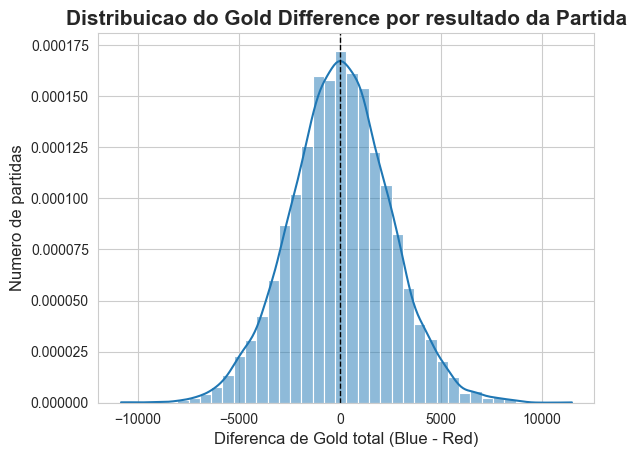

In [14]:
sns.histplot(data=df_only_diff,
             x="diff_TotalGold",
             bins=40,
             kde=True,
             alpha=0.5,
             stat="density" )

plt.axvline(0, color="black", linestyle="--", linewidth=1, )

plt.title("Distribuicao do Gold Difference por resultado da Partida", fontsize=15, weight="bold")
plt.xlabel("Diferenca de Gold total (Blue - Red)", fontsize=12)
plt.ylabel("Numero de partidas", fontsize=12)

A diferença total de gold entre Blue e Red é normalmente próxima de zero, com a maioria das partidas sendo equilibradas, e poucas partidas apresentando vantagens extremas. Diferenças grandes (±10k) representam vitórias dominantes e são raras.

Text(0, 0.5, 'Gold')

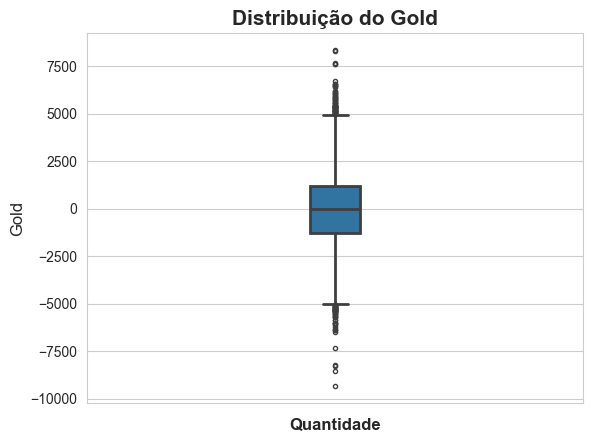

In [15]:
sns.boxplot(data=df_only_diff,
            y="diff_TotalExperience",
            width=0.1,
            linewidth=2,
            fliersize=3
            )

plt.title('Distribuição do Gold', fontsize=15, weight='bold')
plt.xlabel('Quantidade', fontsize=12, weight='bold')
plt.ylabel('Gold', fontsize=12)


A maior parte das partidas tem diferença de gold pequena/moderada, centrada em zero, mas existem jogos extremos (outliers) com vantagens enormes, que são raros.

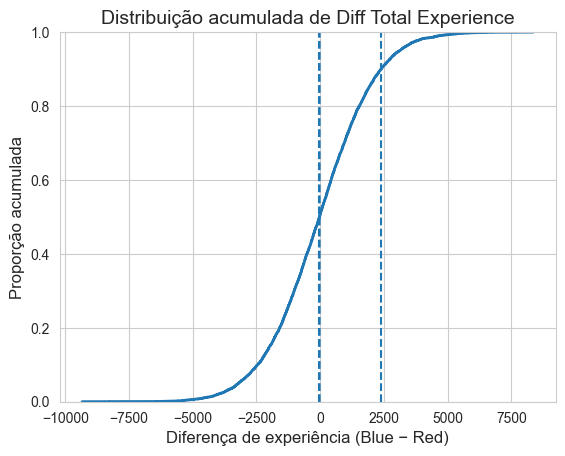

In [16]:
sns.ecdfplot(data=df_only_diff,
             x='diff_TotalExperience',
             linewidth=2,)

p50 = df_only_diff["diff_TotalExperience"].median()
p90 = df_only_diff["diff_TotalExperience"].quantile(0.9)

plt.axvline(p50, linestyle="--", label="Mediana")
plt.axvline(p90, linestyle="--", label="90% dos jogos abaixo disso")

plt.title("Distribuição acumulada de Diff Total Experience", fontsize=14)
plt.xlabel("Diferença de experiência (Blue − Red)", fontsize=12)
plt.ylabel("Proporção acumulada", fontsize=12)

plt.axvline(0, linestyle="--", alpha=0.6)

Utilizei ECDF para analisar a distribuição acumulada do diff_TotalExperience, permitindo observar percentis e a proporção de partidas equilibradas ou extremamente desbalanceadas.
Embora gráficos como histograma sejam mais comuns, o ECDF oferece uma leitura estatística mais robusta, especialmente para comparação entre variáveis.

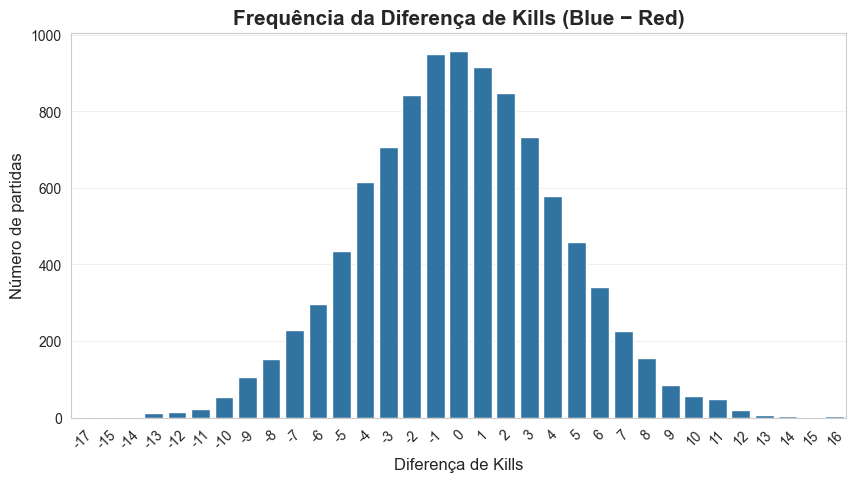

In [17]:
counts = df_only_diff['diff_Kills'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=counts.index, y=counts.values)

plt.title("Frequência da Diferença de Kills (Blue − Red)", fontsize=15, weight='bold')
plt.xlabel("Diferença de Kills", fontsize=12)
plt.ylabel("Número de partidas", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


A diferenca de kills apresenta distribuicao aproximadamente normal centrada em zero, indicando que a maioria das partidas e equilibrada em abates. No entanto, existem outliers representando partidas dominadas por um dos lados. Essa variavel tem alto potencial preditivo, pois grandes vantagens em kills geralmente se traduzem em maior chance de vitoria.”

# Analise bivariada

In [18]:
paleta = {
    False: "red",
    True: "blue"
}

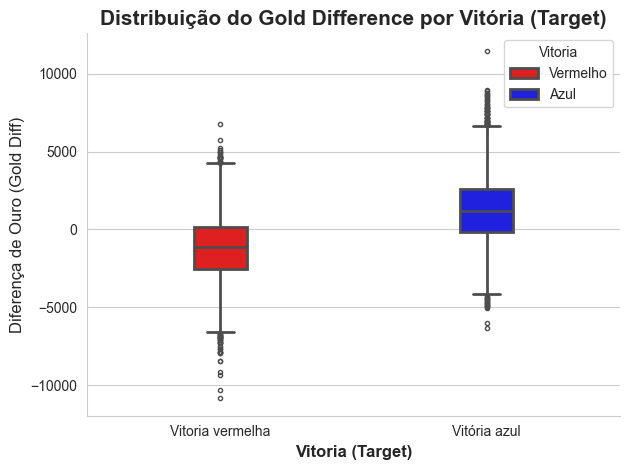

In [19]:
sns.set_style("whitegrid")

sns.boxplot(
    data=df_only_diff,
    x="target",
    y="diff_TotalGold",
    palette= paleta,
    hue='target',
    width=0.2,
    linewidth=2,
    fliersize=3
)

plt.title('Distribuição do Gold Difference por Vitória (Target)', fontsize=15, weight='bold')
plt.legend(title="Vitoria", labels=["Vermelho", "Azul"])
plt.xlabel('Vitoria (Target)', fontsize=12, weight='bold')
plt.ylabel('Diferença de Ouro (Gold Diff)', fontsize=12)
plt.xticks([0,1], ["Vitoria vermelha", "Vitória azul"])


sns.despine()
plt.tight_layout()

Como podemos notar o time azul lidera com porcentagem de outro obtido, consequentemente de vitoria

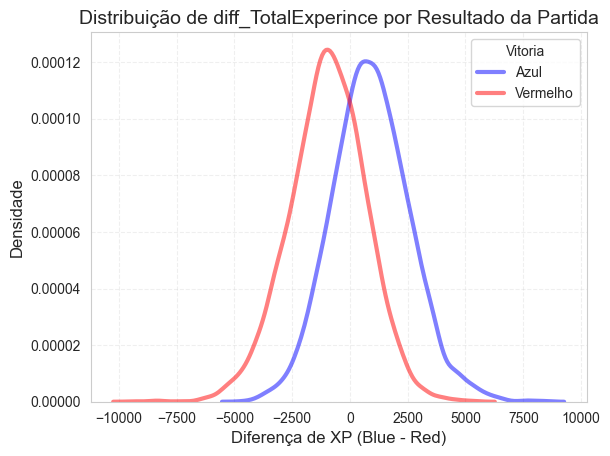

In [20]:
sns.kdeplot(data=df_only_diff,
            x='diff_TotalExperience',
            hue='target',
            palette=paleta,
            linewidth=3,
            alpha=0.5,
            )
plt.title("Distribuição de diff_TotalExperince por Resultado da Partida", fontsize=14)
plt.xlabel("Diferença de XP (Blue - Red)", fontsize=12)
plt.ylabel("Densidade", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Vitoria", labels=["Azul", "Vermelho"])

Aqui temos um exemplo visual do quanto fica equilibrado o jogo quando os dois times tem uma porcentagem parecida de kills

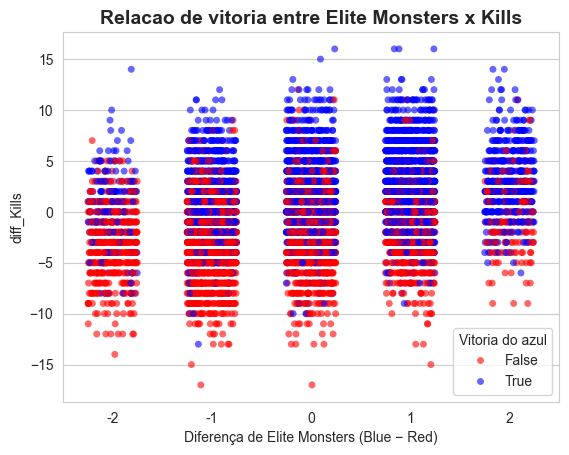

In [21]:
sns.stripplot(
    data=df_only_diff,
    x="diff_EliteMonsters",
    y="diff_Kills",
    hue="target",
    jitter=0.25,
    alpha=0.6,
    palette=paleta
)

plt.title("Relacao de vitoria entre Elite Monsters x Kills", fontsize=14, weight="bold")
plt.xlabel("Diferença de Elite Monsters (Blue − Red)")
plt.legend(title="Vitoria do azul")


o grafico evidencia uma forte correlacao entre controle de Elite Monsters e vitória. Mesmo em partidas onde o time azul possui desvantagem em kills, a vantagem em objetivos como dragoes e barão frequentemente resulta em vitória, reforcando que objetivos estrategicos tem maior impacto do que abates isolados.”

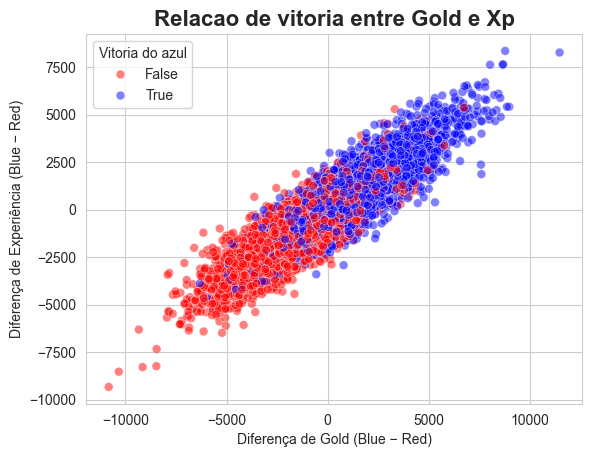

In [22]:
sns.scatterplot(data=df_only_diff,
                x='diff_TotalGold',
                y='diff_TotalExperience',
                hue='target',
                alpha=0.5,
                s=40,
                palette=paleta
                )

plt.title("Relacao de vitoria entre Gold e Xp", fontsize=16, weight="bold")
plt.xlabel("Diferença de Gold (Blue − Red)")
plt.ylabel("Diferença de Experiência (Blue − Red)")
plt.legend(title="Vitoria do azul")


Observa-se uma correlacao positiva forte entre diferença de gold e XP, com clara separação entre vitórias e derrotas nos extremos. Isso indica que ambas as variaveis sao fortes indicadores de performance, porem altamente colineares.

# Separacao de treino e teste


In [23]:
X = df_only_diff.drop(columns="target")
y = df_only_diff["target"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
y.value_counts()

target
False    4949
True     4930
Name: count, dtype: int64

Nossa target esta muito bem balanceada, nao precisaremos aplicar tecnicas de balanceamento

# Aplicando o primeiro modelo

In [26]:
model_rf = RandomForestClassifier(n_estimators=300, random_state=42)

In [27]:
model_rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model_rf.predict(X_test)

In [29]:
acuracia = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'acuracia: {acuracia}\\n Report : {cr}\n\n confusion matrix: {cm}')

acuracia: 0.7171052631578947\n Report :               precision    recall  f1-score   support

       False       0.71      0.72      0.72       983
        True       0.72      0.71      0.72       993

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976


 confusion matrix: [[711 272]
 [287 706]]


O modelo apresenta desempenho equilibrado entre as classes, com métricas consistentes de precision, recall e F1-score em torno de 72%. A matriz de confusão indica erros distribuídos de forma simétrica, sugerindo ausência de viés relevante e boa capacidade de generalização, sendo um baseline sólido para evoluções futuras. Mas que pode melhorar, talvez aplicando outras tecnicas como cross validadtion e searchCV. Um "capamento" dos outliers talvez seja interessante nesse caso tambem.

#### Variaveis de maior peso

In [30]:
importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head()

diff_TotalGold                   0.192660
diff_TotalExperience             0.158107
diff_TotalJungleMinionsKilled    0.074945
diff_WardsPlaced                 0.072207
diff_TotalMinionsKilled          0.071378
dtype: float64

Interessante que quando obsevamos na nossa analise de correlacao, algumas dessas tinham baxissima correlacao entre nossa variavel target.


# Aplicando o segundo modelo

In [31]:
model_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

In [32]:
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [33]:
y_pred_xgb = model_xgb.predict(X_test)

In [34]:
acuracia = accuracy_score(y_test, y_pred_xgb)
cr = classification_report(y_test, y_pred_xgb)
cm = confusion_matrix(y_test, y_pred_xgb)

print(f'acuracia: {acuracia}\\n Report : {cr}\n\n confusion matrix: {cm}')

acuracia: 0.7307692307692307\n Report :               precision    recall  f1-score   support

       False       0.73      0.74      0.73       983
        True       0.74      0.73      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976


 confusion matrix: [[724 259]
 [273 720]]


ficou claro que nosso xgboost deve praticamente o mesmo desempenho do random forest, nao obtivemos mudancas significativas aqui. Toda via, ele obteve um desempenho levemente melhor, entao daremos continuidade com ele.

# Melhorando o modelo

In [43]:
param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [44]:
print("Melhores parâmetros:", search.best_params_)
print("Melhor score:", search.best_score_)

Melhores parâmetros: {'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1}
Melhor score: 0.7262196240369778


# Conclusao

Apos otimizacao com ramdomizedsearchCV, o xgboost alcançou score de 0,726 com parâmetros que controlam profundidade, quantidade minima de amostrar para criacao de um novo no, ganho minimo e numero de arvores indicando um modelo mais generalizavel. O ganho marginal sugere que melhorias futuras estão mais relacionadas à qualidade das features do que ao ajuste do algoritmo, como tratamento de outliers.